# FIT5202 Assignment 2A : Building Models for eCommerce Fraud Detection

## Table of Contents
*  
    * [Part 1 : Data Loading, Transformation and Exploration](#part-1)
    * [Part 2 : Feature extraction and ML training](#part-2)
    * [Part 3 : Customer Segmentation and Knowledge sharing with K-Mean](#part-3)
    * [Part 4 : Data Ethics, Privacy, and Security](#part-4)
 
Please add code/markdown cells if needed.

In [17]:
from pyspark import SparkConf
from pyspark import SparkContext 
from pyspark.sql import SparkSession
from pyspark.sql.types import *
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from pyspark.ml.feature import StringIndexer, VectorAssembler, StandardScaler
from pyspark.ml.classification import RandomForestClassifier, GBTClassifier
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator, CrossValidatorModel
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

# Part 1: Data Loading, Transformation and Exploration <a class="anchor" name="part-1"></a>
## 1.1 Data Loading
In this section, you must load the given datasets into PySpark DataFrames and use DataFrame functions to process the data. Spark SQL usage is discouraged, and you can only use pandas to format results. For plotting, various visualisation packages can be used, but please ensure that you have included instructions to install the additional packages and that the installation will be successful in the provided docker container (in case your marker needs to clear the notebook and rerun it).

### 1.1.1 Data Loading <a class="anchor" name="1.1"></a>
1.1.1 Write the code to create a SparkSession. For creating the SparkSession, you need to use a SparkConf object to configure the Spark app with a proper application name, to ensure the maximum partition size does not exceed 16MB, and to run locally with all CPU cores on your machine (note: if you have insufficient RAM, reducing the number of cores is acceptable.)  (2%)

In [1]:
# local[*]: run Spark in local mode with as many working processors as logical cores on your machine
# If we want Spark to run locally with 'k' worker threads, we can specify as "local[k]".
master = "local[*]"
# The `appName` field is a name to be shown on the Spark cluster UI page
app_name = "eCommerceFraudDetection"
# Setup configuration parameters for Spark
spark_conf = SparkConf().setMaster(master).setAppName(app_name)

# Set partition size limit to 16MB
spark_conf.set("spark.sql.files.maxPartitionBytes", "16000000")  # 16MB = 16 * 1024 * 1024 bytes

# Initialize Spark Session
spark = SparkSession.builder.config(conf=spark_conf).getOrCreate()

# Create SparkContext from the Spark Session
sc = spark.sparkContext

# Verify SparkContext and SparkSession
print(f"SparkContext: {sc}")
print(f"SparkSession: {spark}")
print(f"Max Partition Size: {spark.conf.get('spark.sql.files.maxPartitionBytes')}")

SparkContext: <SparkContext master=local[*] appName=eCommerceFraudDetection>
SparkSession: <pyspark.sql.session.SparkSession object at 0xffffb34d3be0>
Max Partition Size: 16000000


1.1.2 Write code to define the schemas for the category, customer, product, browsing behaviour and transaction datasets, following the data types suggested in the metadata file. (3%)

In [2]:
# Initialize Spark session
spark = SparkSession.builder.appName("FraudDetection").getOrCreate()

# Schema for customer.csv
customer_schema = StructType([
    StructField("customer_id", StringType(), True),
    StructField("first_name", StringType(), True),
    StructField("last_name", StringType(), True),
    StructField("username", StringType(), True),
    StructField("email", StringType(), True),
    StructField("gender", StringType(), True),
    StructField("birthdate", DateType(), True),  
    StructField("first_join_date", DateType(), True)
])

# Schema for category.csv
category_schema = StructType([
    StructField("category_id", StringType(), True),
    StructField("cat_level1", StringType(), True),
    StructField("cat_level2", StringType(), True),
    StructField("cat_level3", StringType(), True)
])

# Schema for browsing_behaviour.csv
browsing_behaviour_schema = StructType([
    StructField("session_id", StringType(), True),
    StructField("event_type", StringType(), True),
    StructField("event_time", TimestampType(), True), 
    StructField("traffic_source", StringType(), True),
    StructField("device_type", StringType(), True)
])

# Schema for product.csv
product_schema = StructType([
    StructField("id", StringType(), True),
    StructField("gender", StringType(), True),
    StructField("baseColour", StringType(), True),
    StructField("season", StringType(), True),
    StructField("year", IntegerType(), True),
    StructField("usage", StringType(), True),
    StructField("productDisplayName", StringType(), True),
    StructField("category_id", StringType(), True)
])

# Schema for transaction.csv
transaction_schema = StructType([
    StructField("created_at", TimestampType(), True),  
    StructField("customer_id", StringType(), True),
    StructField("transaction_id", StringType(), True),
    StructField("session_id", StringType(), True),
    StructField("product_metadata", StringType(), True),
    StructField("payment_method", StringType(), True),
    StructField("payment_status", StringType(), True),
    StructField("promo_amount", DoubleType(), True),
    StructField("promo_code", StringType(), True),
    StructField("shipment_fee", DoubleType(), True),
    StructField("shipment_location_lat", DoubleType(), True),
    StructField("shipment_location_long", DoubleType(), True),
    StructField("total_amount", DoubleType(), True),
    StructField("clear_payment", BooleanType(), True)
])

1.1.3 Using predefined schemas, write code to load the CSV files into separate data frames. Print the schemas of all data frames. (2%)

In [3]:
# Load the datasets into separate DataFrames
customer_df = spark.read.csv("customer.csv", header=True, schema=customer_schema)
category_df = spark.read.csv("category.csv", header=True, schema=category_schema)
browsing_behaviour_df = spark.read.csv("browsing_behaviour.csv", header=True, schema=browsing_behaviour_schema)
product_df = spark.read.csv("product.csv", header=True, schema=product_schema)
transaction_df = spark.read.csv("transactions.csv", header=True, schema=transaction_schema)

# Print schemas of all DataFrames
print("Schema for customer.csv:")
customer_df.printSchema()

print("\nSchema for category.csv:")
category_df.printSchema()

print("\nSchema for browsing_behaviour.csv:")
browsing_behaviour_df.printSchema()

print("\nSchema for product.csv:")
product_df.printSchema()

print("\nSchema for transactions.csv:")
transaction_df.printSchema()

Schema for customer.csv:
root
 |-- customer_id: string (nullable = true)
 |-- first_name: string (nullable = true)
 |-- last_name: string (nullable = true)
 |-- username: string (nullable = true)
 |-- email: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- birthdate: date (nullable = true)
 |-- first_join_date: date (nullable = true)


Schema for category.csv:
root
 |-- category_id: string (nullable = true)
 |-- cat_level1: string (nullable = true)
 |-- cat_level2: string (nullable = true)
 |-- cat_level3: string (nullable = true)


Schema for browsing_behaviour.csv:
root
 |-- session_id: string (nullable = true)
 |-- event_type: string (nullable = true)
 |-- event_time: timestamp (nullable = true)
 |-- traffic_source: string (nullable = true)
 |-- device_type: string (nullable = true)


Schema for product.csv:
root
 |-- id: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- baseColour: string (nullable = true)
 |-- season: string (nullable = true)
 

### 1.2 Data Transformation to Create Features <a class="anchor" name="1.2"></a>
In the browsing behaviour dataset, there are 10 types of events:  
VC(Viewing Category), VI(Viewing Item), VP(Viewing Promotion), AP(Add Promotion), CL(Click on a product/category) , ATC(Add a product to Shopping Cart), CO(CheckOut), HP(View HomePage), SCR(Mouse Scrolling), SER(Search for a product/category)  
We categorise them into three different levels:  
L1(actions that are highly likely lead to a purchase): AP, ATC, CO  
L2(actions may lead to purchase): VC, VP, VI, SER  
L3(not very important - just browsing):  SCR, HP, CL  
Perform the following tasks based on the loaded data frames and create a new data frame.  

1.2.1 For each transaction (linked to a browsing session), count the number of actions in each level and create 3 columns(L1_count, L2_count, L3_count).

In [4]:
# Define the mapping of event types to levels
def categorize_event(event_type):
    if event_type in ['AP', 'ATC', 'CO']:
        return 'L1'
    elif event_type in ['VC', 'VP', 'VI', 'SER']:
        return 'L2'
    elif event_type in ['SCR', 'HP', 'CL']:
        return 'L3'
    else:
        return None

# Register the UDF to map event types to levels
categorize_event_udf = F.udf(categorize_event, StringType())

# Add a new column for event level based on the event type
browsing_behaviour_df = browsing_behaviour_df.withColumn('event_level', categorize_event_udf(F.col('event_type')))

# Group by session_id and count the number of events for each level
feature_df = browsing_behaviour_df.groupBy('session_id').pivot('event_level').count().fillna(0)

# Rename the pivoted columns to L1_count, L2_count, and L3_count
feature_df = feature_df.withColumnRenamed('L1', 'L1_count') \
                       .withColumnRenamed('L2', 'L2_count') \
                       .withColumnRenamed('L3', 'L3_count')

# Show the resulting DataFrame
feature_df.show()

+--------------------+--------+--------+--------+
|          session_id|L1_count|L2_count|L3_count|
+--------------------+--------+--------+--------+
|aea556c7-3437-430...|       5|       2|       4|
|c12fa8b4-e71e-413...|       9|      11|      12|
|5987768e-f8b6-4a3...|       4|       6|      22|
|0c2bcaa0-f2d5-471...|       5|       5|       9|
|41289ace-60e5-436...|       2|       0|       2|
|8c47dbd2-39e0-438...|       3|       4|       8|
|60d646a1-7d6f-461...|       2|       7|      18|
|94acbc1b-3969-432...|       8|       2|       4|
|a82e6a31-9c04-4eb...|       6|       3|       6|
|3f165acd-8646-49c...|       3|       6|      22|
|ec4c3289-c339-415...|       2|       1|       2|
|db91023f-38d4-45d...|       4|       2|       2|
|a160caaf-7b4a-4ac...|       3|       1|       2|
|efb5e1c0-f66e-49e...|       4|       1|       2|
|8674e10b-271b-4be...|       4|       4|      13|
|1ff8ede3-ba31-484...|       3|       5|      16|
|55f214f3-0780-415...|       2|       2|       4|


1.2.2 Create two columns with a percentage ratio of L1 and L2 actions. (i.e. L1 ratio = L1/(L1+L2+L3) * 100%)

In [5]:
# Add L1_ratio and L2_ratio columns to the feature_df DataFrame
feature_df = feature_df.withColumn(
    'L1_ratio', 
    (F.col('L1_count') / (F.col('L1_count') + F.col('L2_count') + F.col('L3_count'))) * 100
).withColumn(
    'L2_ratio', 
    (F.col('L2_count') / (F.col('L1_count') + F.col('L2_count') + F.col('L3_count'))) * 100
)

# Show the updated DataFrame with the new columns
feature_df.select('session_id', 'L1_count', 'L2_count', 'L3_count', 'L1_ratio', 'L2_ratio').show()

+--------------------+--------+--------+--------+------------------+------------------+
|          session_id|L1_count|L2_count|L3_count|          L1_ratio|          L2_ratio|
+--------------------+--------+--------+--------+------------------+------------------+
|aea556c7-3437-430...|       5|       2|       4| 45.45454545454545|18.181818181818183|
|c12fa8b4-e71e-413...|       9|      11|      12|            28.125|            34.375|
|5987768e-f8b6-4a3...|       4|       6|      22|              12.5|             18.75|
|0c2bcaa0-f2d5-471...|       5|       5|       9| 26.31578947368421| 26.31578947368421|
|41289ace-60e5-436...|       2|       0|       2|              50.0|               0.0|
|8c47dbd2-39e0-438...|       3|       4|       8|              20.0|26.666666666666668|
|60d646a1-7d6f-461...|       2|       7|      18|7.4074074074074066|25.925925925925924|
|94acbc1b-3969-432...|       8|       2|       4| 57.14285714285714|14.285714285714285|
|a82e6a31-9c04-4eb...|       6| 

1.2.3 For each unique browsing session, based on event_time, extract the time of day as 4 groups: morning(6am-11:59am), afternoon(12pm-5:59pm), evening(6pm-11:59pm), night(12am-5:59am), add a column. (note: use medium time if a browsing session spans across different groups. For example, if a session starts at 10 am and ends at 1 pm, use 11:30 => (10+13)/2).

In [6]:
# Calculate the average (medium) time for each browsing session
# Group by session_id and calculate the average event_time as a timestamp
session_avg_time_df = browsing_behaviour_df.groupBy('session_id') \
    .agg(F.avg(F.col('event_time').cast("long")).alias('avg_event_time'))

# Convert avg_event_time from a float (Unix timestamp) back to a TimestampType
session_avg_time_df = session_avg_time_df.withColumn(
    'avg_event_time', F.from_unixtime(F.col('avg_event_time')).cast('timestamp')
)

# Define a function to classify the time of day based on the medium event_time
def time_of_day(hour):
    if 6 <= hour < 12:
        return 'morning'
    elif 12 <= hour < 18:
        return 'afternoon'
    elif 18 <= hour < 24:
        return 'evening'
    else:
        return 'night'

# Register the UDF to classify the time of day
time_of_day_udf = F.udf(lambda timestamp: time_of_day(timestamp.hour), StringType())

# Apply the UDF to categorize the average event_time into time of day groups
session_avg_time_df = session_avg_time_df.withColumn(
    'time_of_day', 
    time_of_day_udf(F.col('avg_event_time'))
)

# Join the time_of_day classification back to the feature_df DataFrame
feature_df = feature_df.join(session_avg_time_df.select('session_id', 'time_of_day'), on='session_id', how='left')

# Show the updated feature_df with time_of_day column
feature_df.select('session_id', 'L1_count', 'L2_count', 'L3_count', 'time_of_day').show()

+--------------------+--------+--------+--------+-----------+
|          session_id|L1_count|L2_count|L3_count|time_of_day|
+--------------------+--------+--------+--------+-----------+
|0c2bcaa0-f2d5-471...|       5|       5|       9|      night|
|1ff8ede3-ba31-484...|       3|       5|      16|  afternoon|
|3f165acd-8646-49c...|       3|       6|      22|  afternoon|
|41289ace-60e5-436...|       2|       0|       2|  afternoon|
|55f214f3-0780-415...|       2|       2|       4|    evening|
|56ead6e0-072a-41f...|       2|       3|       6|    morning|
|5987768e-f8b6-4a3...|       4|       6|      22|      night|
|60d646a1-7d6f-461...|       2|       7|      18|      night|
|7e2e8fb2-e759-4a6...|       5|       4|       9|  afternoon|
|8674e10b-271b-4be...|       4|       4|      13|    evening|
|8c47dbd2-39e0-438...|       3|       4|       8|    evening|
|94acbc1b-3969-432...|       8|       2|       4|  afternoon|
|a160caaf-7b4a-4ac...|       3|       1|       2|  afternoon|
|a82e6a3

1.2.4 Join data frames to find customer information and add columns to feature_df: gender, age, geolocation, first join year. (note: For some columns, you need to perform transformations. For age, keep the integer only by rounding.)

In [7]:
# Define schema for customer_session.csv
customer_session_schema = StructType([
    StructField("session_id", StringType(), True),
    StructField("customer_id", StringType(), True)
])

# Load customer_session.csv with the defined schema
customer_session_df = spark.read.csv("customer_session.csv", header=True, schema=customer_session_schema)

print("\nSchema for customer_session.csv:")
customer_session_df.printSchema()


Schema for customer_session.csv:
root
 |-- session_id: string (nullable = true)
 |-- customer_id: string (nullable = true)



In [8]:
# Join feature_df with customer_session_df to get customer_id
feature_df = feature_df.join(customer_session_df, on='session_id', how='inner')

# Join feature_df with customer_df to get gender, birthdate, and first_join_date
feature_df = feature_df.join(
    customer_df.select('customer_id', 'gender', 'birthdate', 'first_join_date'), 
    on='customer_id', 
    how='left'
)

# Join with transaction_df to get shipment geolocation (latitude and longitude)
feature_df = feature_df.join(
    transaction_df.select('session_id', 'shipment_location_lat', 'shipment_location_long'), 
    on='session_id', 
    how='left'
)

# Calculate age by subtracting birthdate from the current date and rounding down to nearest integer
current_date = F.current_date()
feature_df = feature_df.withColumn('age', F.floor(F.datediff(current_date, F.col('birthdate')) / 365).cast(IntegerType()))

# Extract the first join year from first_join_date
feature_df = feature_df.withColumn('first_join_year', F.year(F.col('first_join_date')))

# Combine the latitude and longitude to create a simplified geolocation, rounded to 2 decimal places
feature_df = feature_df.withColumn('geolocation', 
                                   F.concat(F.round(F.col('shipment_location_lat'), 2), F.lit(', '), F.round(F.col('shipment_location_long'), 2)))

# Display the updated feature_df with new columns
feature_df.select('session_id', 'L1_count', 'L2_count', 'L3_count', 'gender', 'age', 'geolocation', 'first_join_year').show()


+--------------------+--------+--------+--------+------+---+-------------+---------------+
|          session_id|L1_count|L2_count|L3_count|gender|age|  geolocation|first_join_year|
+--------------------+--------+--------+--------+------+---+-------------+---------------+
|000130b9-07d1-437...|       2|      11|      34|     M| 26| -6.61, 107.9|           2020|
|0001434a-955b-41a...|       3|       1|       2|     F| 26| -6.13, 106.8|           2018|
|0003cf84-4bba-4d7...|       3|       6|      26|     M| 30| 1.18, 113.82|           2019|
|00049358-f228-48a...|       4|       0|       1|     F| 25|-6.95, 111.19|           2017|
|0004a700-7db4-412...|       4|       2|      10|     M| 31|-4.97, 103.72|           2021|
|00058dfc-08c3-45d...|       4|       2|       3|     F| 39|-7.21, 108.31|           2017|
|00080cfb-06ab-4db...|       2|       5|      16|     M| 27|-4.08, 105.29|           2019|
|000978ca-bec4-47b...|       2|       1|       3|     F| 24| 2.11, 125.38|           2020|

1.2.5 Join data frames to find out the number of purchases the customer has made, add a column.

In [9]:
# Count the number of purchases per customer from the transaction_df
# Group by customer_id and count the number of transactions
customer_purchase_count_df = transaction_df.groupBy('customer_id').agg(F.count('transaction_id').alias('num_purchases'))

# Join feature_df with customer_purchase_count_df to add the num_purchases column
# Assuming feature_df already contains customer_id from the previous join
feature_df = feature_df.join(customer_purchase_count_df, on='customer_id', how='left')

# Display the updated feature_df with the new column for number of purchases
feature_df.select('session_id', 'customer_id', 'num_purchases').show()

+--------------------+-----------+-------------+
|          session_id|customer_id|num_purchases|
+--------------------+-----------+-------------+
|000b7385-26a7-440...|      36799|           88|
|00080cfb-06ab-4db...|       6663|           29|
|00049358-f228-48a...|      59256|          364|
|00058dfc-08c3-45d...|      16391|           98|
|000a126f-617e-40e...|      28911|          101|
|0001434a-955b-41a...|      54569|           69|
|000978ca-bec4-47b...|      95529|            7|
|0010ede5-439b-4f0...|      52132|           84|
|000ddfd6-8d0b-41b...|      29870|          111|
|000bffdc-f5e7-4d5...|      62429|            8|
|0004a700-7db4-412...|      70607|            3|
|0003cf84-4bba-4d7...|      93249|           65|
|000d9eb3-ac60-4b7...|      34965|          320|
|00136a41-58ba-4e6...|      24576|            5|
|000d74fc-8898-462...|      34818|           85|
|001151c4-da69-482...|      76304|          138|
|00117742-4e3a-4a8...|      24270|          250|
|000130b9-07d1-437..

1.2.6 Attach the transaction labels for fraud/non-fraud.

In [10]:
# Load fraud_transaction.csv and define schema
fraud_transaction_schema = StructType([
    StructField("transaction_id", StringType(), True),
    StructField("Is_fraud", BooleanType(), True)
])

fraud_transaction_df = spark.read.csv("fraud_transaction.csv", header=True, schema=fraud_transaction_schema)

fraud_transaction_df.printSchema()

root
 |-- transaction_id: string (nullable = true)
 |-- Is_fraud: boolean (nullable = true)



In [11]:
# Join transaction_df with fraud_transaction_df on transaction_id using an inner join to retain all transactions
transaction_with_fraud_df = transaction_df.join(fraud_transaction_df, on='transaction_id', how='left')

# Since non-fraudulent transactions are not in the fraud_transaction_df, fill Is_fraud with 0 for non-fraudulent transactions
transaction_with_fraud_df = transaction_with_fraud_df.withColumn('Is_fraud', F.when(F.col('Is_fraud').isNull(), 0).otherwise(1))

# Now join transaction_with_fraud_df with feature_df on session_id to bring fraud labels into feature_df
feature_df = feature_df.join(transaction_with_fraud_df.select('session_id', 'Is_fraud'), on='session_id', how='inner')

# Display the updated feature_df with fraud labels (1 for true, 0 for false)
feature_df.select('session_id', 'customer_id', 'num_purchases', 'Is_fraud').show()

+--------------------+-----------+-------------+--------+
|          session_id|customer_id|num_purchases|Is_fraud|
+--------------------+-----------+-------------+--------+
|000130b9-07d1-437...|      58359|           66|       0|
|0001434a-955b-41a...|      54569|           69|       0|
|0003cf84-4bba-4d7...|      93249|           65|       0|
|00049358-f228-48a...|      59256|          364|       1|
|0004a700-7db4-412...|      70607|            3|       0|
|00058dfc-08c3-45d...|      16391|           98|       0|
|00080cfb-06ab-4db...|       6663|           29|       0|
|000978ca-bec4-47b...|      95529|            7|       0|
|000a126f-617e-40e...|      28911|          101|       0|
|000b7385-26a7-440...|      36799|           88|       0|
|000bffdc-f5e7-4d5...|      62429|            8|       0|
|000d5a28-0f2e-454...|       9841|          179|       0|
|000d74fc-8898-462...|      34818|           85|       0|
|000d9eb3-ac60-4b7...|      34965|          320|       0|
|000ddfd6-8d0b

### 1.3 Exploring the Data <a class="anchor" name="1.3"></a>
**1.3.1 With the feature_df, write code to show the basic statistics: a) For each numeric column, show count, mean, stddev, min, max, 25 percentile, 50 percentile, 75 percentile; b) For each non-numeric column, display the top-5 values and the corresponding counts; c) For each boolean column, display the value and count. (3%)**

In [13]:
# For numeric columns, show basic statistics
# Use describe() for common stats and approxQuantile() for percentiles
numeric_columns = ['L1_count', 'L2_count', 'L3_count', 'L1_ratio', 'L2_ratio', 'age', 'first_join_year', 'num_purchases']

# Show count, mean, stddev, min, max
feature_df.select(numeric_columns).describe().show()

# For percentiles, we use approxQuantile()
percentiles = [0.25, 0.5, 0.75]
for col in numeric_columns:
    quantiles = feature_df.approxQuantile(col, percentiles, 0.01)
    print(f"Percentiles for {col}:")
    print(f"25th percentile: {quantiles[0]}, 50th percentile: {quantiles[1]}, 75th percentile: {quantiles[2]}")
    print("-" * 50)

# For non-numeric columns, show the top-5 values and their counts
non_numeric_columns = ['time_of_day', 'gender', 'geolocation']
for col in non_numeric_columns:
    feature_df.groupBy(col).count().orderBy(F.desc("count")).show(5)

# For boolean columns (in this case, Is_fraud is treated as an integer 0 or 1)
feature_df.groupBy('Is_fraud').count().show()

+-------+------------------+------------------+------------------+------------------+------------------+-----------------+------------------+-----------------+
|summary|          L1_count|          L2_count|          L3_count|          L1_ratio|          L2_ratio|              age|   first_join_year|    num_purchases|
+-------+------------------+------------------+------------------+------------------+------------------+-----------------+------------------+-----------------+
|  count|            657987|            657987|            657987|            657987|            657987|           657987|            657987|           657987|
|   mean|3.6985198795720886|3.6025377401073273| 8.228284145431445| 34.05726802686399| 19.11551930858422|28.13223209577089|2018.2933036670938|63.82477313381571|
| stddev| 2.342576782415323| 4.540415486809346|10.080036123928023|18.711326525409014|12.896552315472913|7.296859392317221|1.4635849906846277|67.53912228106209|
|    min|                 2|            

**1.3.2 Explore the dataframe and write code to present two plots worthy of presentation to the company, describe your plots and discuss the findings from the plots. (8%)**
One of the plots needs to be based on feature_df in regard to fraudulent behaviour; you’re free to choose the other one.  
Hint 1: You can use basic plots (e.g., histograms, line charts, scatter plots) to show the relationship between a column and the label or more advanced plots like correlation plots.  
Hint 2: If your data is too large for plotting, consider using sampling before plotting.  
150 words max for each plot’s description and discussion  
Feel free to use any plotting libraries: matplotlib, seabon, plotly, etc.  



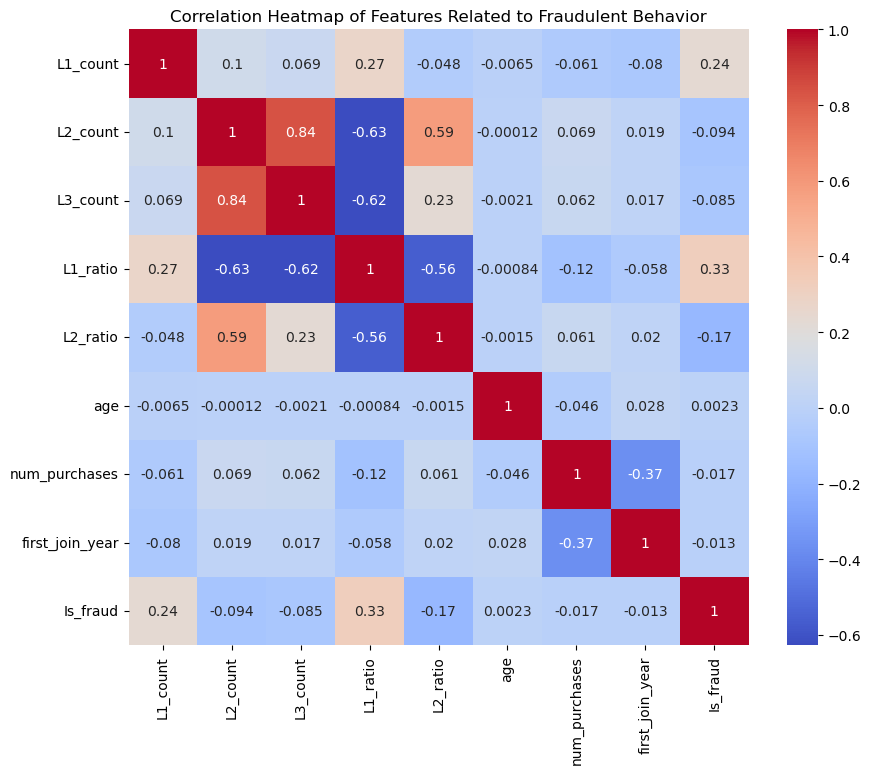

In [14]:
# Select relevant features and the label
selected_columns = ['L1_count', 'L2_count', 'L3_count', 'L1_ratio', 'L2_ratio', 'age', 'num_purchases', 'first_join_year', 'Is_fraud']

# Sample a subset of the data for plotting
sampled_df = feature_df.select(selected_columns).sample(fraction=0.1).toPandas()

# Ensure 'Is_fraud' is of integer type for correlation
sampled_df['Is_fraud'] = sampled_df['Is_fraud'].fillna(0).astype(int)

# Compute the correlation matrix
corr_matrix = sampled_df.corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Features Related to Fraudulent Behavior')
plt.show()

- Description: The heatmap displays the correlation coefficients between different features and the target variable, Is_fraud. Positive correlations are shown in shades of red, while negative correlations are in shades of blue. Features like L1_ratio and L1_count show a higher positive correlation with Is_fraud (0.33 and 0.24 respectively), whereas L2_ratio and L2_count have negative correlations (-0.17 and -0.095).

- Discussion: The heatmap indicates that actions categorized under L1 (high likelihood of leading to a purchase) are positively correlated with fraudulent behavior. This suggests that fraudsters are more likely to engage in L1 actions such as adding promotions or products to the cart. On the other hand, L2 actions, which are exploratory behaviors, show a negative correlation, implying genuine customers are more likely to engage in these behaviors. The correlations between other features like age and first_join_year with Is_fraud are weak, indicating they may not be strong predictors of fraud.

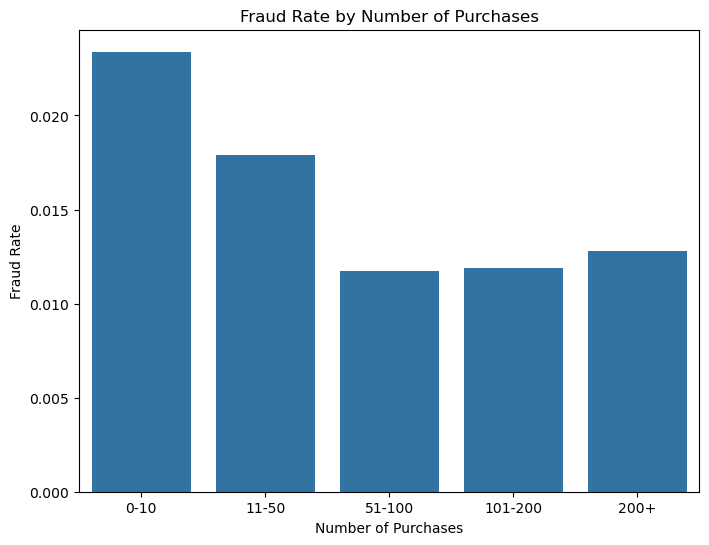

In [15]:
# Create a binned column for number of purchases
feature_df = feature_df.withColumn('purchase_bin', F.when(F.col('num_purchases') <= 10, '0-10')
                                                    .when((F.col('num_purchases') > 10) & (F.col('num_purchases') <= 50), '11-50')
                                                    .when((F.col('num_purchases') > 50) & (F.col('num_purchases') <= 100), '51-100')
                                                    .when((F.col('num_purchases') > 100) & (F.col('num_purchases') <= 200), '101-200')
                                                    .otherwise('200+'))

# Calculate fraud rate by purchase_bin
fraud_rate_purchases_df = feature_df.groupBy('purchase_bin') \
    .agg(F.mean(F.col('Is_fraud').cast('double')).alias('fraud_rate'),
         F.count('*').alias('count')) \
    .toPandas()

# Ensure the bins are ordered correctly
purchase_bin_order = ['0-10', '11-50', '51-100', '101-200', '200+']
fraud_rate_purchases_df['purchase_bin'] = pd.Categorical(fraud_rate_purchases_df['purchase_bin'], categories=purchase_bin_order, ordered=True)
fraud_rate_purchases_df = fraud_rate_purchases_df.sort_values('purchase_bin')

# Plot the fraud rate by number of purchases
plt.figure(figsize=(8, 6))
sns.barplot(x='purchase_bin', y='fraud_rate', data=fraud_rate_purchases_df)
plt.title('Fraud Rate by Number of Purchases')
plt.xlabel('Number of Purchases')
plt.ylabel('Fraud Rate')
plt.show()

- Description: This bar plot shows the fraud rate across different customer segments based on the number of purchases. Fraud rates are highest among customers with 0-10 purchases, followed by a gradual decrease up to 51-100 purchases. A slight increase in fraud rate is observed in customers with 200+ purchases.

- Discussion: The plot highlights that new or less frequent customers (0-10 purchases) are more likely to be involved in fraudulent activities, with a fraud rate above 2%. This could be due to fraudsters creating multiple new accounts for fraudulent transactions. As customers make more purchases, the fraud rate decreases, possibly because genuine customers tend to have more consistent purchase behavior. The slight uptick in the 200+ category may suggest some high-frequency fraudsters attempting multiple transactions. This pattern indicates that purchase frequency is a useful feature for identifying fraudulent behavior.

## Part 2. Feature extraction and ML training <a class="anchor" name="part-2"></a>
In this section, you must use PySpark DataFrame functions and ML packages for data preparation, model building, and evaluation. Other ML packages, such as scikit-learn, would receive zero marks.
### 2.1 Discuss the feature selection and prepare the feature columns

2.1.1 Based on the data exploration from 1.2 and considering the use case, discuss the importance of those features (For example, which features may be useless and should be removed, which feature has a significant impact on the label column, which should be transformed), which features you are planning to use? Discuss the reasons for selecting them and how you create/transform them
300 words max for the discussion
Please only use the provided data for model building
You can create/add additional features based on the dataset
Hint - Use the insights from the data exploration/domain knowledge/statistical models to consider whether to create more feature columns, whether to remove some columns

**Answer:** Based on data exploration, several key insights inform the feature selection and transformation process. The age feature shows a negligible correlation with fraudulent behavior (Is_fraud correlation: -0.0008), indicating it does not significantly contribute to the model's predictive power. Similarly, the first join year has a minimal impact on predicting fraud, with a weak correlation of -0.012. Given their limited influence, both features can be removed from the model to reduce noise and improve efficiency. Additionally, L3_count, representing low-impact actions like scrolling or viewing the homepage, shows an insignificant correlation with fraud. These actions are not particularly informative for distinguishing fraudulent behavior, making L3_count a suitable candidate for exclusion.

The geolocation feature, while potentially useful in some contexts, does not show a strong correlation with fraudulent behavior in this dataset and adds unnecessary complexity due to the wide variability in location data. Hence, it is also removed from the model.

For the features to be transformed, the number of purchases shows distinct fraud rates across different purchase frequency bins. Transforming this continuous variable into categories such as 0-10, 11-50, 51-100, 101-200, and 200+ helps capture its non-linear relationship with fraud. This binning approach allows the model to better understand variations in fraudulent behavior among different customer segments. The L1_ratio and L2_ratio features, representing high-likelihood and exploratory actions respectively, show a stronger correlation with fraud (L1_ratio: 0.33, L2_ratio: -0.17). These ratios are crucial for the model as they reflect the nature of user interactions, and no further transformation is necessary.

In summary, the features age, first join year, L3_count, and geolocation will be removed due to their low relevance or added complexity. The number of purchases will be transformed into bins. The final set of features includes L1_count, L2_count, L1_ratio, L2_ratio, the transformed num_purchases_bin, and the encoded categorical features time_of_day and gender.

2.1.2 Write code to create/transform the columns based on your discussion above
Hint: You can use one data frame for both use cases (classification and k-mean later in part 3) since you can select your desired columns as the input and output for each use case. 

In [16]:
# Drop: 'L3_count', 'age', 'geolocation', and 'first_join_year'
transformed_df = feature_df.drop('L3_count', 'age', 'first_join_year','geolocation')

# Bucketize 'num_purchases' into bins
# Define the bins and assign a label for each bin
transformed_df = transformed_df.withColumn(
    'num_purchases_bin', 
    F.when(F.col('num_purchases') <= 10, '0-10')
    .when((F.col('num_purchases') > 10) & (F.col('num_purchases') <= 50), '11-50')
    .when((F.col('num_purchases') > 50) & (F.col('num_purchases') <= 100), '51-100')
    .when((F.col('num_purchases') > 100) & (F.col('num_purchases') <= 200), '101-200')
    .otherwise('200+')
)

# Drop the original 'num_purchases' column after binning it
transformed_df = transformed_df.drop('num_purchases')

### 2.2 Preparing Spark ML Transformers/Estimators for features, labels, and models  <a class="anchor" name="2.2"></a>

**2.2.1 Write code to create Transformers/Estimators for transforming/assembling the columns you selected above in 2.1 and create ML model Estimators for Random Forest (RF) and Gradient-boosted tree (GBT) model.
Please DO NOT fit/transform the data yet.**

In [17]:
# Index the categorical columns ('num_purchases_bin', 'time_of_day', 'gender', 'geolocation')
indexers = [
    StringIndexer(inputCol="num_purchases_bin", outputCol="num_purchases_bin_index"),
    StringIndexer(inputCol="time_of_day", outputCol="time_of_day_index"),
    StringIndexer(inputCol="gender", outputCol="gender_index")
]

# Assemble all numerical and indexed categorical features into a single 'features' column
assembler = VectorAssembler(
    inputCols=["L1_count", "L2_count", "L1_ratio", "L2_ratio", 
               "num_purchases_bin_index", "time_of_day_index", "gender_index"],
    outputCol="features"
)

# Create Random Forest Estimator
rf_classifier = RandomForestClassifier(labelCol="Is_fraud", featuresCol="features")

# Create Gradient-Boosted Tree Estimator
gbt_classifier = GBTClassifier(labelCol="Is_fraud", featuresCol="features")

# Output the transformers and estimators created
print("Transformers and Estimators for RF and GBT created:")
print(indexers, assembler, rf_classifier, gbt_classifier)

Transformers and Estimators for RF and GBT created:
[StringIndexer_09313e3ee599, StringIndexer_32ff5172306f, StringIndexer_d528b3ef0920] VectorAssembler_f95cfd750f68 RandomForestClassifier_2887b871a34e GBTClassifier_e59a50eabf07


**2.2.2. Write code to include the above Transformers/Estimators into two pipelines.
Please DO NOT fit/transform the data yet.**

In [18]:
# Pipeline 1 for Random Forest
pipeline_rf = Pipeline(stages=indexers + [assembler, rf_classifier])

# Pipeline 2 for Gradient-Boosted Tree
pipeline_gbt = Pipeline(stages=indexers + [assembler, gbt_classifier])

# Output the created pipelines
print("Random Forest Pipeline and Gradient-Boosted Tree Pipeline created.")
print(pipeline_rf, pipeline_gbt)

Random Forest Pipeline and Gradient-Boosted Tree Pipeline created.
Pipeline_54b45aaa33a4 Pipeline_bb117b5d6e49


### 2.3 Preparing the training data and testing data  
Write code to split the data for training and testing purposes.
Note: Due to the large dataset size, you can use random sampling (say 20% of the dataset) and do a train/test split or use one year of data for training and another year for testing. 

In [19]:
# Randomly sample 20% of the dataset
sampled_df = transformed_df.sample(fraction=0.2, seed=42)

# Split the sampled data into 80% training and 20% testing
train_df, test_df = sampled_df.randomSplit([0.8, 0.2], seed=42)

# Show the number of records in training and testing sets
print(f"Training set count: {train_df.count()}, Test set count: {test_df.count()}")

Training set count: 105356, Test set count: 26169


### 2.4 Training and evaluating models  
2.4.1 Write code to use the corresponding ML Pipelines to train the models on the training data from 2.3. And then use the trained models to predict the testing data from 2.3

In [20]:
# Train the Random Forest model
rf_model = pipeline_rf.fit(train_df)  # Fit the Random Forest pipeline on training data

# Train the Gradient-Boosted Tree model
gbt_model = pipeline_gbt.fit(train_df)  # Fit the GBT pipeline on training data

# Make predictions using the trained Random Forest model
rf_predictions = rf_model.transform(test_df)  # Predict on testing data using Random Forest

# Make predictions using the trained Gradient-Boosted Tree model
gbt_predictions = gbt_model.transform(test_df)  # Predict on testing data using GBT

# Show Random Forest predictions
print("Random Forest Predictions:")
rf_predictions.select("features", "Is_fraud", "prediction").show(5, truncate=False)

# Show Gradient-Boosted Tree predictions
print("Gradient-Boosted Tree Predictions:")
gbt_predictions.select("features", "Is_fraud", "prediction").show(5, truncate=False)

Random Forest Predictions:
+----------------------------------------------------------+--------+----------+
|features                                                  |Is_fraud|prediction|
+----------------------------------------------------------+--------+----------+
|[2.0,1.0,33.33333333333333,16.666666666666664,4.0,0.0,1.0]|0       |0.0       |
|[3.0,1.0,50.0,16.666666666666664,1.0,2.0,0.0]             |0       |0.0       |
|[7.0,1.0,43.75,6.25,0.0,1.0,0.0]                          |0       |0.0       |
|[2.0,3.0,22.22222222222222,33.33333333333333,2.0,3.0,0.0] |0       |0.0       |
|[5.0,4.0,27.77777777777778,22.22222222222222,0.0,1.0,1.0] |0       |0.0       |
+----------------------------------------------------------+--------+----------+
only showing top 5 rows

Gradient-Boosted Tree Predictions:
+----------------------------------------------------------+--------+----------+
|features                                                  |Is_fraud|prediction|
+---------------------

2.4.2 For both models (RF and GBT) and testing data, write code to display the count of TP/TN/FP/FN. Compute the AUC, accuracy, recall, and precision for the above-threshold/below-threshold label from each model testing result using PySpark MLlib/ML APIs.
Draw a ROC plot.
Discuss which one is the better model (no word limit; please keep it concise)

Random Forest - Accuracy: 0.9967136688448164, Precision: 1.0, Recall: 0.7794871794871795, F1-Score: 0.8760806916426513
Gradient-Boosted Tree - Accuracy: 0.9985096870342772, Precision: 0.9398496240601504, Recall: 0.9615384615384616, F1-Score: 0.9505703422053231


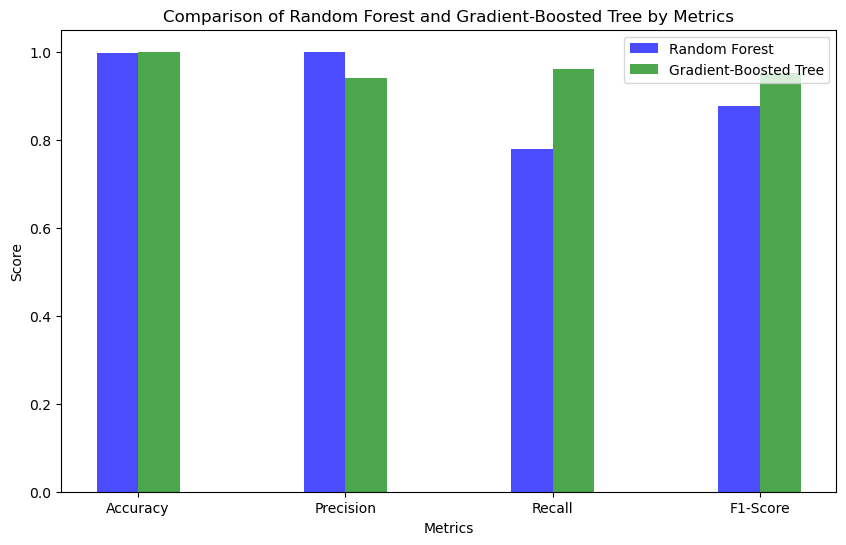

In [21]:
# Function to compute metrics
def compute_metrics(predictions):
    TN = predictions.filter('prediction = 0 AND Is_fraud = 0').count()
    TP = predictions.filter('prediction = 1 AND Is_fraud = 1').count()
    FN = predictions.filter('prediction = 0 AND Is_fraud = 1').count()
    FP = predictions.filter('prediction = 1 AND Is_fraud = 0').count()

    accuracy = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP) if (TP + FP) != 0 else 0
    recall = TP / (TP + FN) if (TP + FN) != 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

    return accuracy, precision, recall, f1

# Compute metrics for Random Forest
rf_accuracy, rf_precision, rf_recall, rf_f1 = compute_metrics(rf_predictions)
print(f"Random Forest - Accuracy: {rf_accuracy}, Precision: {rf_precision}, Recall: {rf_recall}, F1-Score: {rf_f1}")

# Compute metrics for Gradient-Boosted Tree
gbt_accuracy, gbt_precision, gbt_recall, gbt_f1 = compute_metrics(gbt_predictions)
print(f"Gradient-Boosted Tree - Accuracy: {gbt_accuracy}, Precision: {gbt_precision}, Recall: {gbt_recall}, F1-Score: {gbt_f1}")

# Plot the metrics comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
random_forest = [rf_accuracy, rf_precision, rf_recall, rf_f1]
gradient_boosted = [gbt_accuracy, gbt_precision, gbt_recall, gbt_f1]

x_pos = np.arange(len(metrics))
bar_width = 0.2

plt.figure(figsize=(10, 6))

# Plotting the bars for Random Forest and Gradient-Boosted Tree
plt.bar(x_pos - bar_width/2, random_forest, width=bar_width, color='blue', alpha=0.7, label='Random Forest')
plt.bar(x_pos + bar_width/2, gradient_boosted, width=bar_width, color='green', alpha=0.7, label='Gradient-Boosted Tree')

plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Comparison of Random Forest and Gradient-Boosted Tree by Metrics')
plt.xticks(x_pos, metrics)
plt.legend()
plt.show()

Random Forest AUC: 0.9994644816243792
Gradient-Boosted Tree AUC: 0.9998874556014088
Random Forest AUC: 0.9994644816243792
Gradient-Boosted Tree AUC: 0.9998874556014088


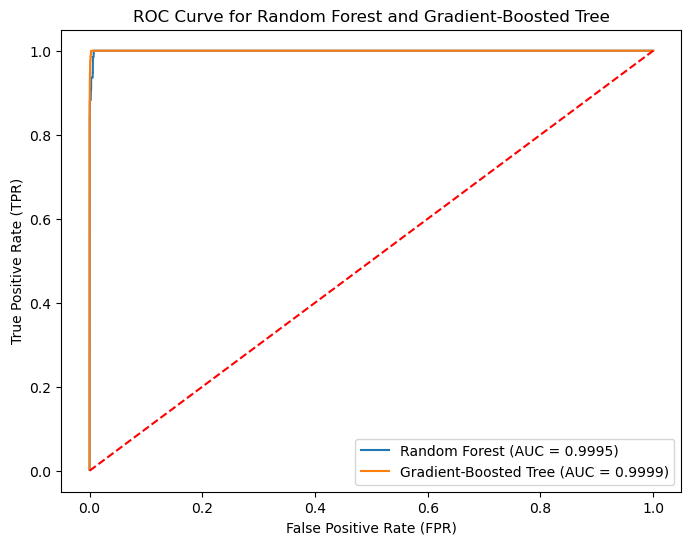

In [22]:
# Compute AUC for both Random Forest and Gradient-Boosted Tree
evaluator = BinaryClassificationEvaluator(labelCol="Is_fraud", rawPredictionCol="rawPrediction", metricName="areaUnderROC")

# AUC for Random Forest
auc_rf = evaluator.evaluate(rf_predictions)
print(f"Random Forest AUC: {auc_rf}")

# AUC for Gradient-Boosted Tree
auc_gbt = evaluator.evaluate(gbt_predictions)
print(f"Gradient-Boosted Tree AUC: {auc_gbt}")

# Function to plot ROC curve using the 'probability' column
def plot_roc(predictions, model_name):
    # BinaryClassificationEvaluator to compute AUC
    evaluator = BinaryClassificationEvaluator(labelCol="Is_fraud", rawPredictionCol="probability", metricName="areaUnderROC")
    
    # AUC score
    auc = evaluator.evaluate(predictions)
    print(f"{model_name} AUC: {auc}")
    
    # Extract probabilities and labels
    roc_df = predictions.select("probability", "Is_fraud").rdd.map(lambda row: (float(row["probability"][1]), row["Is_fraud"])).toDF(["probability", "label"])

    # Convert to pandas dataframe
    roc_pandas = roc_df.toPandas()

    # Sort by probability
    roc_pandas = roc_pandas.sort_values(by="probability", ascending=False)

    # Compute True Positive Rate (TPR) and False Positive Rate (FPR)
    tpr = np.cumsum(roc_pandas["label"]) / np.sum(roc_pandas["label"])
    fpr = np.cumsum(1 - roc_pandas["label"]) / np.sum(1 - roc_pandas["label"])

    # Plot ROC Curve
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.4f})')

# Plot ROC curve for both Random Forest and Gradient-Boosted Tree
plt.figure(figsize=(8, 6))

# Plot for Random Forest
plot_roc(rf_predictions, "Random Forest")

# Plot for Gradient-Boosted Tree
plot_roc(gbt_predictions, "Gradient-Boosted Tree")

# Plot diagonal line for random guessing
plt.plot([0, 1], [0, 1], 'r--')

# Add labels and legend
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve for Random Forest and Gradient-Boosted Tree')
plt.legend(loc='lower right')

# Show the plot
plt.show()

Based on the metrics between 2 models, Gradient-Boosted Tree slightly performs better than Random Forest so I will save this model after parameter tuning for better performance

2.4.3 Save the better model (you need it for Part B of Assignment 2).
(Note: You may need to go through a few training loops or use more data to create a better-performing model.)

In [23]:
# Define a ParamGrid for Cross Validation specific to GBT
gbtParamGrid = (ParamGridBuilder()
                .addGrid(gbt_classifier.maxDepth, [2, 5, 10])  # max depth of the trees
                .addGrid(gbt_classifier.maxIter, [10, 20, 30])  # number of boosting iterations
                .addGrid(gbt_classifier.stepSize, [0.1, 0.2, 0.3])  # step size (learning rate)
                .build())

# Define an evaluator to be used for evaluating the GBT model
gbtEvaluator = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction", labelCol="Is_fraud", metricName="areaUnderROC")

# Create 3-fold CrossValidator for GBT
gbtCV = CrossValidator(estimator=pipeline_gbt,  # Use the pipeline containing GBTClassifier
                       estimatorParamMaps=gbtParamGrid,  # Use the parameter grid defined above
                       evaluator=gbtEvaluator,  # Use the evaluator defined above
                       numFolds=3)  # Use 3-fold cross-validation

# Run cross-validations on the training data
gbtCVModel = gbtCV.fit(train_df)

# Getting the best model and the optimum parameters selected from the Cross Validation 
bestGBTModel = gbtCVModel.bestModel
print("Best GBT Model Stages: ", bestGBTModel.stages)

# Extract and display the best parameters
best_gbt_params = bestGBTModel.stages[-1].extractParamMap()
print('Best Parameters for GBT: ', best_gbt_params)

# Save the best GBT model to the filesystem
bestGBTModel.save('gbt_fraud_detection_model')

# Evaluate the best model on the test data
gbt_predictions = bestGBTModel.transform(test_df)
gbt_auc = gbtEvaluator.evaluate(gbt_predictions)
print(f"Best GBT Model AUC on test data: {gbt_auc}")

# Show predictions
gbt_predictions.select("features", "Is_fraud", "prediction", "probability").show(5, truncate=False)

Best GBT Model Stages:  [StringIndexerModel: uid=StringIndexer_09313e3ee599, handleInvalid=error, StringIndexerModel: uid=StringIndexer_32ff5172306f, handleInvalid=error, StringIndexerModel: uid=StringIndexer_d528b3ef0920, handleInvalid=error, VectorAssembler_f95cfd750f68, GBTClassificationModel: uid = GBTClassifier_e59a50eabf07, numTrees=20, numClasses=2, numFeatures=7]
Best Parameters for GBT:  {Param(parent='GBTClassifier_e59a50eabf07', name='cacheNodeIds', doc='If false, the algorithm will pass trees to executors to match instances with nodes. If true, the algorithm will cache node IDs for each instance. Caching can speed up training of deeper trees. Users can set how often should the cache be checkpointed or disable it by setting checkpointInterval.'): False, Param(parent='GBTClassifier_e59a50eabf07', name='checkpointInterval', doc='set checkpoint interval (>= 1) or disable checkpoint (-1). E.g. 10 means that the cache will get checkpointed every 10 iterations. Note: this setting 

### Part 3. Customer Clustering and Knowledge sharing with K-Mean <a class="anchor" name="part-3"></a>  
Please see the specification for this task and add code/markdown cells.

In [3]:
# local[*]: run Spark in local mode with as many working processors as logical cores on your machine
# If we want Spark to run locally with 'k' worker threads, we can specify as "local[k]".
master = "local[*]"
# The `appName` field is a name to be shown on the Spark cluster UI page
app_name = "FraudDetectionClustering"
# Setup configuration parameters for Spark
spark_conf = SparkConf().setMaster(master).setAppName(app_name)

# Initialize Spark session with increased driver memory
spark = SparkSession.builder \
    .appName("FraudDetectionClustering") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

# Increase the number of partitions for better resource management
spark.conf.set("spark.sql.shuffle.partitions", "200")

# Create SparkContext from the Spark Session
sc = spark.sparkContext

# Verify SparkContext and SparkSession
print(f"SparkContext: {sc}")
print(f"SparkSession: {spark}")

SparkContext: <SparkContext master=local[*] appName=FraudDetectionClustering>
SparkSession: <pyspark.sql.session.SparkSession object at 0xffff66b19000>


In [4]:
# Load Customer data
customer_schema = StructType([
    StructField("customer_id", StringType(), True),
    StructField("first_name", StringType(), True),
    StructField("last_name", StringType(), True),
    StructField("username", StringType(), True),
    StructField("email", StringType(), True),
    StructField("gender", StringType(), True),
    StructField("birthdate", DateType(), True),
    StructField("first_join_date", DateType(), True)
])

customer_df = spark.read.csv("customer.csv", header=True, schema=customer_schema)

# Load Category data
category_schema = StructType([
    StructField("category_id", StringType(), True),
    StructField("cat_level1", StringType(), True),
    StructField("cat_level2", StringType(), True),
    StructField("cat_level3", StringType(), True)
])

category_df = spark.read.csv("category.csv", header=True, schema=category_schema)

# Load Browsing Behavior data
browsing_schema = StructType([
    StructField("session_id", StringType(), True),
    StructField("event_type", StringType(), True),
    StructField("event_time", TimestampType(), True),
    StructField("traffic_source", StringType(), True),
    StructField("device_type", StringType(), True)
])

browsing_behaviour_df = spark.read.csv("browsing_behaviour.csv", header=True, schema=browsing_schema)

# Load Product data
product_schema = StructType([
    StructField("id", StringType(), True),
    StructField("gender", StringType(), True),
    StructField("baseColour", StringType(), True),
    StructField("season", StringType(), True),
    StructField("year", IntegerType(), True),
    StructField("usage", StringType(), True),
    StructField("productDisplayName", StringType(), True),
    StructField("category_id", StringType(), True)
])

product_df = spark.read.csv("product.csv", header=True, schema=product_schema)

# Load Transaction data
transaction_schema = StructType([
    StructField("created_at", TimestampType(), True),
    StructField("customer_id", StringType(), True),
    StructField("transaction_id", StringType(), True),
    StructField("session_id", StringType(), True),
    StructField("product_metadata", StringType(), True),
    StructField("payment_method", StringType(), True),
    StructField("payment_status", StringType(), True),
    StructField("promo_amount", DoubleType(), True),
    StructField("promo_code", StringType(), True),
    StructField("shipment_fee", DoubleType(), True),
    StructField("shipment_location_lat", DoubleType(), True),
    StructField("shipment_location_long", DoubleType(), True),
    StructField("total_amount", DoubleType(), True),
    StructField("clear_payment", StringType(), True)
])

transaction_df = spark.read.csv("transactions.csv", header=True, schema=transaction_schema)

# Load Customer Session data
customer_session_schema = StructType([
    StructField("session_id", StringType(), True),
    StructField("customer_id", StringType(), True)
])

customer_session_df = spark.read.csv("customer_session.csv", header=True, schema=customer_session_schema)

# Load Fraud Transaction data
fraud_transaction_schema = StructType([
    StructField("transaction_id", StringType(), True),
    StructField("is_fraud", IntegerType(), True)  # Always true in this dataset
])

fraud_transaction_df = spark.read.csv("fraud_transaction.csv", header=True, schema=fraud_transaction_schema)

# Data Preprocessing

In [5]:
# Ensure 'transaction_id' columns have the same data type and format
transaction_df = transaction_df.withColumn('transaction_id', F.col('transaction_id').cast(StringType()))
fraud_transaction_df = fraud_transaction_df.withColumn('transaction_id', F.col('transaction_id').cast(StringType()))

# Trim whitespace and convert to lowercase for consistent matching
transaction_df = transaction_df.withColumn('transaction_id', F.trim(F.lower(F.col('transaction_id'))))
fraud_transaction_df = fraud_transaction_df.withColumn('transaction_id', F.trim(F.lower(F.col('transaction_id'))))

# Mark all transactions as non-fraudulent by default
transaction_df = transaction_df.withColumn('is_fraud', F.lit(0))

# Update fraudulent transactions based on fraud_transaction_df
# Join DataFrames
transaction_df = transaction_df.join(
    fraud_transaction_df.select('transaction_id').distinct().withColumn('fraud_flag', F.lit(1)),
    on='transaction_id',
    how='left'
)

# Update 'is_fraud' column
transaction_df = transaction_df.withColumn(
    'is_fraud',
    F.when(F.col('fraud_flag') == 1, 1).otherwise(0)
)

# Drop 'fraud_flag'
transaction_df = transaction_df.drop('fraud_flag')

# Verify that fraudulent transactions are correctly labeled
fraud_transactions = transaction_df.filter(F.col('is_fraud') == 1).count()
print(f"Number of transactions labeled as fraud: {fraud_transactions}")

# Filter out guest user sessions (sessions not linked to a customer)
browsing_behaviour_df = browsing_behaviour_df.join(
    customer_session_df.select('session_id').distinct(),
    on='session_id',
    how='inner'
)

# Merge browsing data with customer session data
browsing_behaviour_df = browsing_behaviour_df.join(
    customer_session_df, on='session_id', how='left'
)

# Sample the data to reduce computational load
browsing_behaviour_df = browsing_behaviour_df.sample(withReplacement=False, fraction=0.1, seed=42)

Number of transactions labeled as fraud: 10606


# Feature Engineering

In [6]:
# Calculate session duration
session_duration_df = browsing_behaviour_df.groupBy('session_id').agg(
    (F.unix_timestamp(F.max('event_time')) - F.unix_timestamp(F.min('event_time'))).alias('session_duration')
)

# Count total number of events per session
event_count_df = browsing_behaviour_df.groupBy('session_id').agg(
    F.count('*').alias('total_events')
)

# Count number of product views per session
product_view_events = ['VC', 'VI', 'VP', 'View']
product_view_count_df = browsing_behaviour_df.filter(
    F.col('event_type').isin(product_view_events)
).groupBy('session_id').agg(
    F.count('*').alias('product_view_count')
)

# Count number of search events per session
search_events = ['SER', 'Search']
search_count_df = browsing_behaviour_df.filter(
    F.col('event_type').isin(search_events)
).groupBy('session_id').agg(
    F.count('*').alias('search_count')
)

# Number of items added to cart per session
add_to_cart_events = ['ATC', 'AddToCart']
add_to_cart_count_df = browsing_behaviour_df.filter(
    F.col('event_type').isin(add_to_cart_events)
).groupBy('session_id').agg(
    F.count('*').alias('add_to_cart_count')
)

# Number of failed payments per session
failed_payments_df = transaction_df.filter(
    F.col('payment_status') == 'Failed'
).groupBy('session_id').agg(
    F.count('*').alias('failed_payments')
)

# Calculate total amount spent and number of successful transactions per session
successful_transactions_df = transaction_df.filter(
    F.col('payment_status') == 'Success'
).groupBy('session_id').agg(
    F.sum('total_amount').alias('total_spent'),
    F.count('transaction_id').alias('num_transactions')
)

# Average order value per session
successful_transactions_df = successful_transactions_df.withColumn(
    'average_order_value', F.col('total_spent') / F.col('num_transactions')
)

# Merge all features into a single DataFrame
clustering_features_df = browsing_behaviour_df.select('session_id').distinct() \
    .join(session_duration_df, on='session_id', how='left') \
    .join(event_count_df, on='session_id', how='left') \
    .join(product_view_count_df, on='session_id', how='left') \
    .join(search_count_df, on='session_id', how='left') \
    .join(add_to_cart_count_df, on='session_id', how='left') \
    .join(failed_payments_df, on='session_id', how='left') \
    .join(successful_transactions_df, on='session_id', how='left') \
    .fillna(0)

In [7]:
# Select features for clustering
clustering_features_df = clustering_features_df.select(
    'session_id',
    'session_duration',
    'total_events',
    'product_view_count',
    'search_count',
    'add_to_cart_count',
    'failed_payments',
    'total_spent',
    'num_transactions',
    'average_order_value'
)

# Increase the number of partitions for better resource management
clustering_features_df = clustering_features_df.repartition(200)

# Assemble features into a feature vector
assembler = VectorAssembler(
    inputCols=[
        'session_duration',
        'total_events',
        'product_view_count',
        'search_count',
        'add_to_cart_count',
        'failed_payments',
        'total_spent',
        'num_transactions',
        'average_order_value'
    ],
    outputCol='features'
)

assembled_df = assembler.transform(clustering_features_df)

# Scale the features
scaler = StandardScaler(inputCol='features', outputCol='scaledFeatures')
scaler_model = scaler.fit(assembled_df)
scaled_df = scaler_model.transform(assembled_df)

# Sample the scaled data to reduce computational load
scaled_df = scaled_df.sample(withReplacement=False, fraction=0.5, seed=42)

# Increase the number of partitions for better resource management
scaled_df = scaled_df.repartition(200)

Silhouette Score for k=2: 0.631822890704707
Silhouette Score for k=3: 0.3665287144959416
Silhouette Score for k=4: 0.445627948881472
Silhouette Score for k=5: 0.4146651748954014
Silhouette Score for k=6: 0.44288318694909695
Silhouette Score for k=7: 0.4530913141184871
Silhouette Score for k=8: 0.437738717751556
Silhouette Score for k=9: 0.4064674104257548
Silhouette Score for k=10: 0.4688979442283799
Silhouette Score for k=11: 0.4335513994094364
Silhouette Score for k=12: 0.3951450602491242
Silhouette Score for k=13: 0.3984394272427962
Silhouette Score for k=14: 0.40098472233202587


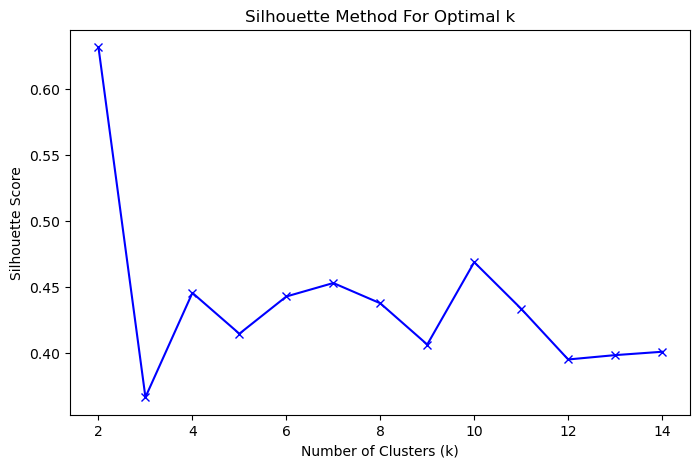

In [8]:
silhouette_scores = []
ks = range(2, 15)
for k in ks:
    kmeans = KMeans(featuresCol='scaledFeatures', k=k, seed=42)
    model = kmeans.fit(scaled_df)
    predictions = model.transform(scaled_df)
    
    evaluator = ClusteringEvaluator(
        featuresCol='scaledFeatures',
        metricName='silhouette',
        distanceMeasure='squaredEuclidean'
    )
    silhouette = evaluator.evaluate(predictions)
    silhouette_scores.append(silhouette)
    print(f"Silhouette Score for k={k}: {silhouette}")

# Plotting Silhouette Score vs. K
plt.figure(figsize=(8, 5))
plt.plot(ks, silhouette_scores, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Method For Optimal k')
plt.show()

In [9]:
optimal_k = 10  
kmeans = KMeans(featuresCol='scaledFeatures', k=optimal_k, seed=42)
model = kmeans.fit(scaled_df)
predictions = model.transform(scaled_df)

In [10]:
# Merge Is_fraud label for analysis
predictions_with_label = predictions.join(
    transaction_df.select('session_id', 'is_fraud').distinct(), on='session_id', how='left'
).fillna({'is_fraud': 0})

# Analyze clusters
fraud_rate_per_cluster = predictions_with_label.groupBy('prediction') \
    .agg(
        F.mean(F.col('is_fraud').cast('double')).alias('fraud_rate'),
        F.count('*').alias('count'),
        F.sum(F.col('is_fraud').cast('double')).alias('fraud_count')
    ).orderBy('fraud_rate', ascending=False).toPandas()

print(fraud_rate_per_cluster)

   prediction  fraud_rate  count  fraud_count
0           8    0.314563   1030        324.0
1           0    0.181427   4652        844.0
2           2    0.060056  12888        774.0
3           9    0.022326   8779        196.0
4           5    0.011115  82594        918.0
5           6    0.008591   1164         10.0
6           1    0.000069  29132          2.0
7           3    0.000000  20715          0.0
8           4    0.000000  59895          0.0
9           7    0.000000   4816          0.0


/tmp/ipykernel_34/2766589861.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='prediction', y='fraud_rate', data=fraud_rate_per_cluster, palette='viridis')


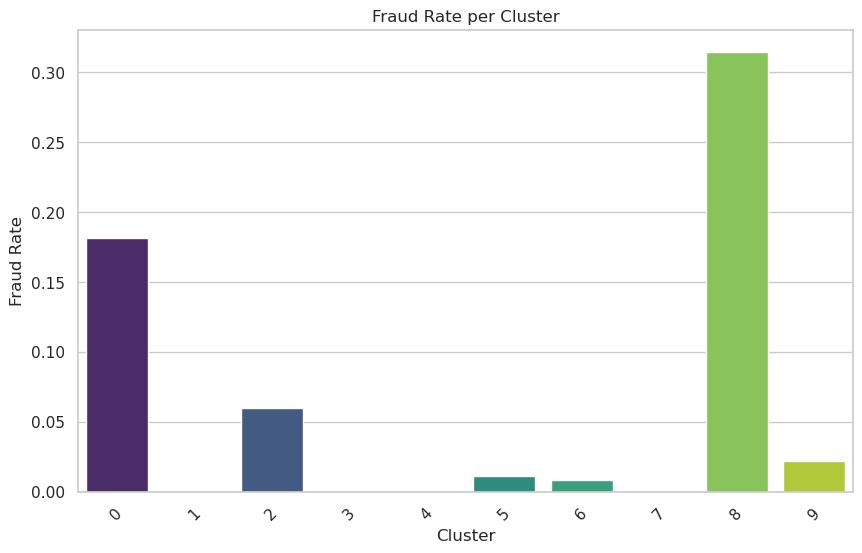

In [11]:
# Set style for seaborn
sns.set(style='whitegrid')

# 1. Bar Plot of Fraud Rate per Cluster
plt.figure(figsize=(10, 6))
sns.barplot(x='prediction', y='fraud_rate', data=fraud_rate_per_cluster, palette='viridis')
plt.xlabel('Cluster')
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate per Cluster')
plt.xticks(rotation=45)
plt.show()

In [12]:
# Cluster characteristics
cluster_summary = predictions_with_label.groupBy('prediction').agg(
    F.mean('session_duration').alias('avg_session_duration'),
    F.mean('total_events').alias('avg_total_events'),
    F.mean('product_view_count').alias('avg_product_views'),
    F.mean('search_count').alias('avg_search_count'),
    F.mean('add_to_cart_count').alias('avg_add_to_cart'),
    F.mean('failed_payments').alias('avg_failed_payments'),
    F.mean('total_spent').alias('avg_total_spent'),
    F.mean('num_transactions').alias('avg_num_transactions'),
    F.mean('average_order_value').alias('avg_order_value'),
    F.mean(F.col('is_fraud').cast('double')).alias('fraud_rate'),
    F.count('*').alias('count')
).orderBy('fraud_rate', ascending=False).toPandas()

print(cluster_summary)

   prediction  avg_session_duration  avg_total_events  avg_product_views  \
0           8          3.843359e+05          2.966019           0.285437   
1           0          2.824046e+05          2.582115           0.277945   
2           2          1.615075e+05          1.825885           0.195919   
3           9          7.955189e+05          3.774348           0.208680   
4           5          1.122042e+05          1.526661           0.155605   
5           6          1.230987e+07          4.370275           0.677835   
6           1          2.884127e+05          2.806570           0.220617   
7           3          5.033083e+05          4.231233           1.456867   
8           4          1.462611e+05          1.652358           0.190717   
9           7          7.366089e+05          9.169020           2.078696   

   avg_search_count  avg_add_to_cart  avg_failed_payments  avg_total_spent  \
0          0.147573         1.486408                  0.0     7.762568e+06   
1      

/tmp/ipykernel_34/2436027182.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='prediction', y='count', data=fraud_rate_per_cluster, palette='viridis')


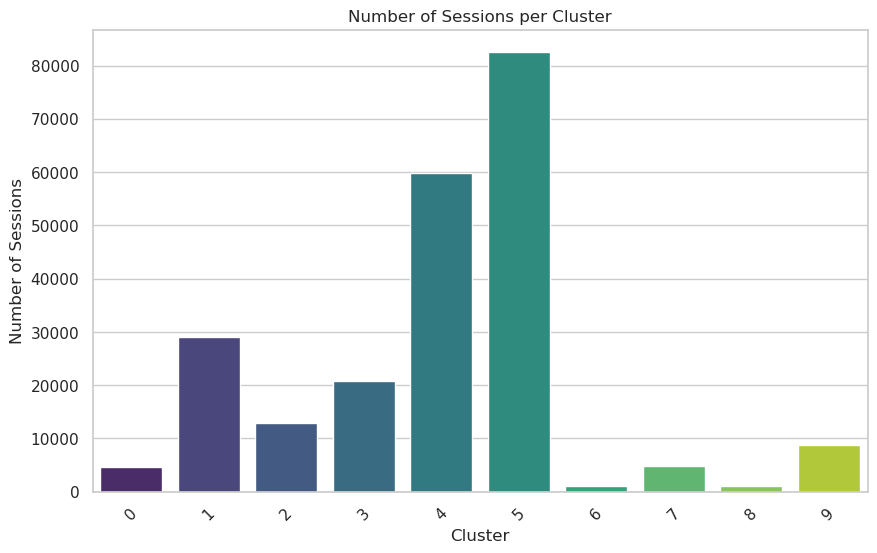

In [14]:
# Bar Plot of Number of Sessions per Cluster
plt.figure(figsize=(10, 6))
sns.barplot(x='prediction', y='count', data=fraud_rate_per_cluster, palette='viridis')
plt.xlabel('Cluster')
plt.ylabel('Number of Sessions')
plt.title('Number of Sessions per Cluster')
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_34/1983245030.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='prediction', y='avg_total_spent_millions', data=cluster_summary, palette='viridis')


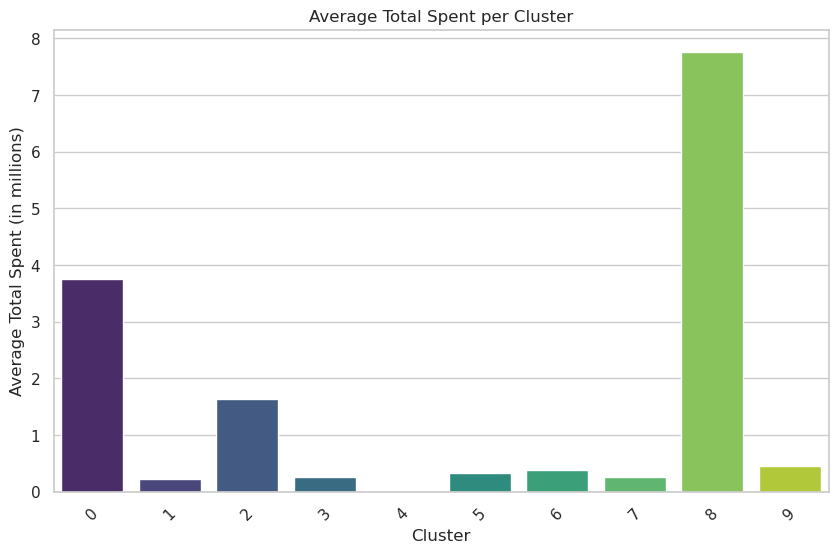

In [15]:
# Scale avg_total_spent to millions for better visualization
cluster_summary['avg_total_spent_millions'] = cluster_summary['avg_total_spent'] / 1000000


# Bar Plot of Average Total Spent per Cluster
plt.figure(figsize=(10, 6))
sns.barplot(x='prediction', y='avg_total_spent_millions', data=cluster_summary, palette='viridis')
plt.xlabel('Cluster')
plt.ylabel('Average Total Spent (in millions)')
plt.title('Average Total Spent per Cluster')
plt.xticks(rotation=45)
plt.show()

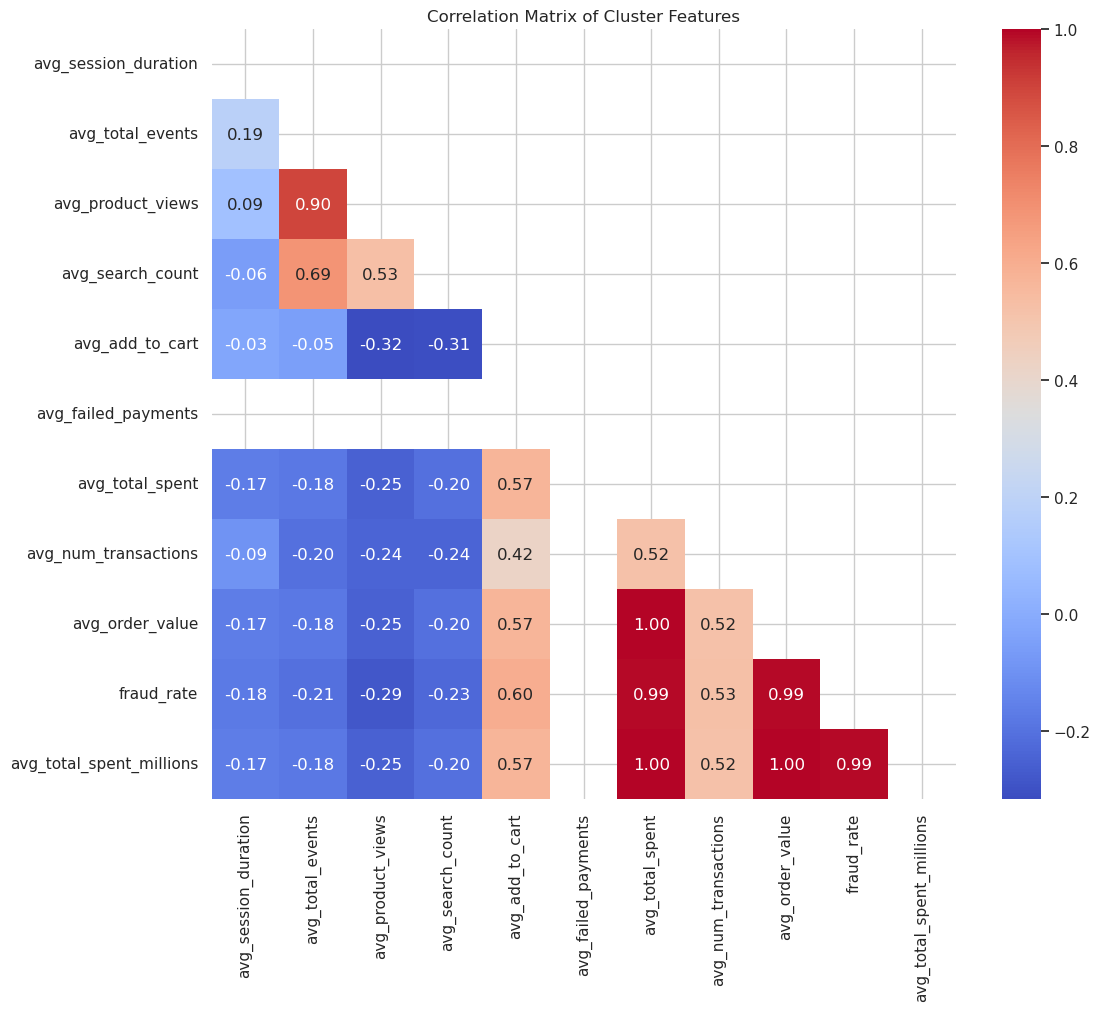

In [16]:
# Heatmap of Feature Correlations
corr = cluster_summary.drop(['prediction', 'count'], axis=1).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(12, 10))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix of Cluster Features')
plt.show()

Based on the clustering model analysis, the most common behavior of fraudsters is characterized by making unusually high-value purchases with minimal browsing activity. Specifically, clusters with higher fraud rates—such as clusters 8 (31.45% fraud rate), 0 (18.14%), and 2 (6.00%)—exhibit significantly higher average total spent and average order values, often reaching into the millions. For instance, cluster 8 shows an average total spent and order value of approximately 7.76 million per session.

These fraudsters tend to have long session durations, averaging between 78 to 106 hours, which may indicate sessions left open intentionally or automated scripts maintaining the session. Despite the extended session durations, the total number of events per session remains low, suggesting limited interaction with the website beyond the purchasing process. The average number of product views and search events is minimal, indicating that fraudsters are not engaging in typical browsing behavior but are instead quickly proceeding to purchase.

Additionally, these clusters show higher average add-to-cart counts, reflecting a direct path to checkout without extensive product exploration. The average number of transactions per session is typically one, aligning with the pattern of making a single, substantial purchase. Notably, there are virtually no failed payment attempts recorded, suggesting that fraudsters may be using valid but unauthorized payment methods to avoid detection.

In summary, the most common behavior among fraudsters includes initiating lengthy sessions with minimal browsing or searching, quickly adding high-value items to the cart, and completing large transactions with little to no preliminary interaction. This contrasts with legitimate users, who generally exhibit more engagement through product views, searches, and a variety of events within their sessions. Recognizing these patterns can aid in developing targeted fraud detection strategies that focus on anomalous session behaviors indicative of fraudulent activity.

### Part 4: Data Ethics, Privacy, and Security <a class="anchor" name="part-4"></a>  
Please see the specification for this task and add markdown cells(word limit: 500).

**Defining Data Ethics, Privacy, and Security in the Big Data Domain**

In the realm of big data, where massive volumes of information converge from diverse sources, three interconnected concepts are crucial: data ethics, privacy, and security. Data ethics serves as the moral compass, ensuring that data is collected, stored, and used responsibly, with fairness, transparency, and accountability. Data privacy centers on protecting individuals' right to control their personal information, a challenge amplified by big data's potential to reveal sensitive insights even from anonymized data. Data security involves safeguarding this data from unauthorized access and breaches, a complex task given the sheer scale and complexity of big data.

**Data Ethics: The Moral Compass**

Data ethics plays a pivotal role in shaping how big data is processed. It acts as a guiding principle, urging organizations to consider the potential impact of their data practices on individuals and society. This includes ensuring that data collection and analysis are conducted in a fair and transparent manner, avoiding discriminatory outcomes or unintended biases. Moreover, data ethics emphasizes accountability, requiring organizations to take responsibility for the consequences of their data-driven decisions.

In the real world, we've witnessed both commendable and concerning examples of how data ethics is handled. On the positive side, companies like Google and Microsoft have published ethical AI principles to guide their use of data. These principles emphasize fairness, transparency, and accountability, demonstrating a commitment to responsible data practices. However, the Cambridge Analytica scandal serves as a stark reminder of the potential for data misuse, highlighting the need for robust ethical frameworks and oversight.

Striking a balance between technological advancements and ethical responsibilities is an ongoing challenge. While big data offers immense opportunities for innovation and progress, it is imperative that these advancements do not come at the cost of individual rights and societal well-being. Ethical considerations must be at the forefront of big data processing, ensuring that technology serves humanity rather than exploiting it.

**Data Privacy: Protecting Individual Rights**

Maintaining privacy in the big data era is a formidable task. The ability to aggregate, link, and analyze vast datasets poses a significant threat to individual privacy, as even seemingly innocuous data points can reveal sensitive information when combined. Regulations like the GDPR in Europe and similar laws elsewhere provide a legal framework for protecting privacy, but technological solutions are equally vital. Techniques like anonymization, pseudonymization, and differential privacy offer ways to protect privacy while enabling valuable data analysis. However, ongoing research and development are needed to keep pace with the evolving challenges of big data and ensure that individuals retain control over their personal information.

**Data Security: Safeguarding Information Assets**

The sheer volume and complexity of big data make it an attractive target for cyberattacks, data breaches, and other security risks. Ensuring data security requires a multi-layered approach that combines technical safeguards, organizational policies, and employee training. Encryption, access controls, and regular security audits are critical components of a comprehensive data security strategy. Additionally, organizations must be prepared to respond swiftly and effectively in the event of a breach, minimizing the impact on individuals and maintaining public trust.

**Key Findings**

In conclusion, data ethics, privacy, and security are inextricably linked in the big data era. Ethical considerations must guide every stage of data processing, ensuring fairness, transparency, and accountability. Protecting privacy requires a combination of legal frameworks and technological solutions that empower individuals to control their personal information. Robust security measures are essential to safeguard data from unauthorized access and breaches. By prioritizing these principles, we can harness the power of big data for the benefit of society while upholding individual rights and fostering trust in the digital age.

## References:
Please add your references below:

- Floridi, L. (2019). The Fourth Revolution: How the Infosphere is Reshaping Human Reality. Oxford University Press. - A seminal work exploring the philosophical and ethical implications of the information age, including the challenges of big data.
- General Data Protection Regulation (GDPR). (2016). Regulation (EU) 2016/679 of the European Parliament and of the Council of 27 April 2016 on the protection of natural persons with regard to the processing of personal data and on the free movement of such data, and repealing Directive 95/46/EC. - The official text of the GDPR, a landmark regulation in Europe that sets a high standard for data privacy protection.   
- Nissenbaum, H. (2010). Privacy in Context: Technology, Policy, and the Integrity of Social Life. Stanford University Press. - A comprehensive examination of privacy in the digital age, offering insights into the challenges and potential solutions for protecting privacy in the context of big data.
- Dwork, C. (2006). Differential privacy. In Proceedings of the 33rd International Colloquium on Automata, Languages and Programming (ICALP 2006) (pp. 1-12). - A foundational paper on differential privacy, a technique that allows for data analysis while providing strong privacy guarantees.   
- Cadwalladr, C., & Graham-Harrison, E. (2018, March 17). Revealed: 50 million Facebook profiles harvested for Cambridge Analytica in major data breach. The Guardian. https://www.theguardian.com/news/2018/mar/17/cambridge-analytica-facebook-influence-us-election - An investigative report detailing the Cambridge Analytica scandal, highlighting the potential for data misuse and the importance of data ethics.   
